# Telco Customer Churn EDA, Preprocessing & Training

## 1. Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
pd.set_option('display.max_columns', None)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [6]:
print("\nChurn distribution:\n", df['Churn Label'].value_counts())


Churn distribution:
 Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
print("\nChurn %:\n", df['Churn Label'].value_counts(normalize=True) * 100)


Churn %:
 Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


#### 73% doesn't churn and 73% values in `Churn Reason` is empty i.e customers who didn't churn doesn't have a churn reason, so drop `Churn Reason`

In [8]:
df.drop(columns=['Churn Reason'], inplace = True)
df.shape

(7043, 32)

####  `Total Charges` is loaded as an object instead of float —> Convert it into float

In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [10]:
print("NaNs in TotalCharges after conversion:", df['Total Charges'].isnull().sum())

NaNs in TotalCharges after conversion: 11


In [11]:
df[df['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342


#### The blank entries in `Total Charges` correspond to new customers with `Tenure` = 0 who have never been billed. Since 11 rows is only ~0.15% of the dataset, we can drop them safely

### Drop `Churn Label`

In [12]:
df.dropna(inplace = True)
df.drop(columns = ['Churn Label'], inplace = True)
df.shape

(7032, 31)

### Class Imbalance Check

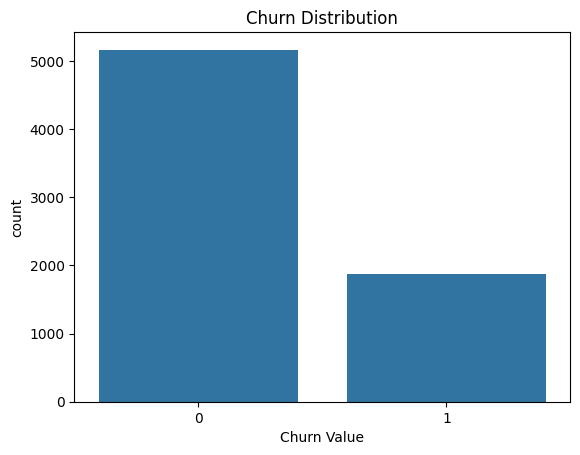

In [13]:
sns.countplot(x='Churn Value', data=df)
plt.title('Churn Distribution')
plt.show()

### Numeric Distributions

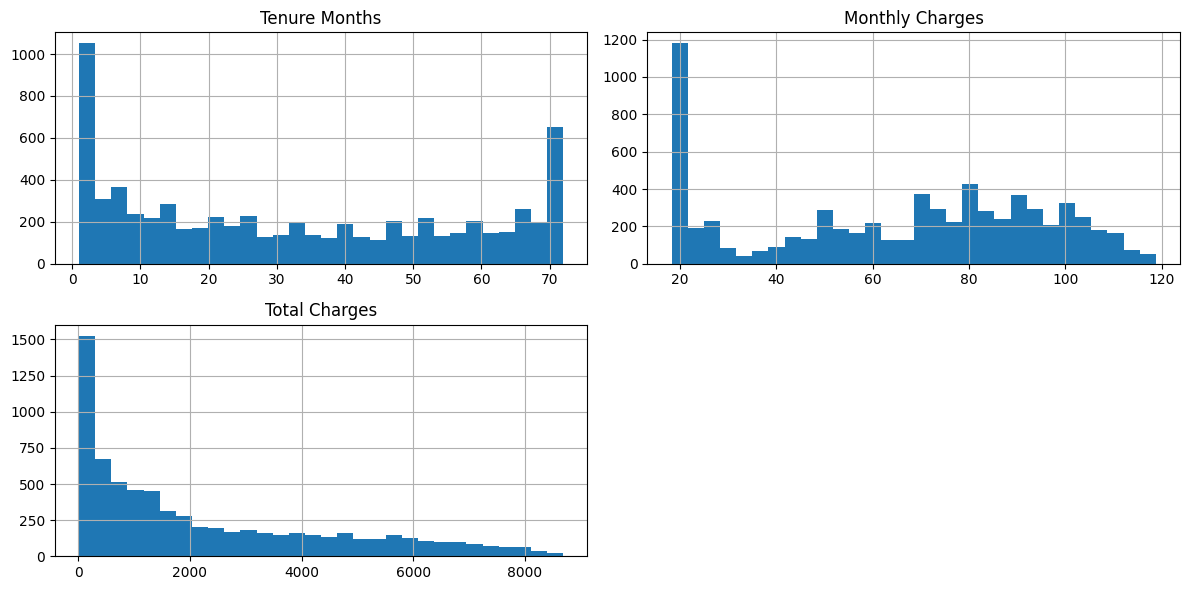

In [14]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
df[num_cols].hist(bins=30, figsize=(12, 6))
plt.tight_layout()
plt.show()

### Observation
- **Tenure Months**: Bimodal distribution with a large spike at month 1 (new, high-risk
  customers) and another at month 72 (long-term loyal customers). Tenure is likely one
  of the strongest churn predictor
- **Monthly Charges**: Peaks at `~20$` (basic plan users) then spreads broadly up to `120$`.
  Higher monthly charges likely push customers toward churn.
- **Total Charges**: Right-skewed distribution, indicating that most customers have low cumulative spending, while a small proportion of long-tenured customers contribute to very high total charges.

### Customer Churn Analysis Across Key Categorical Features

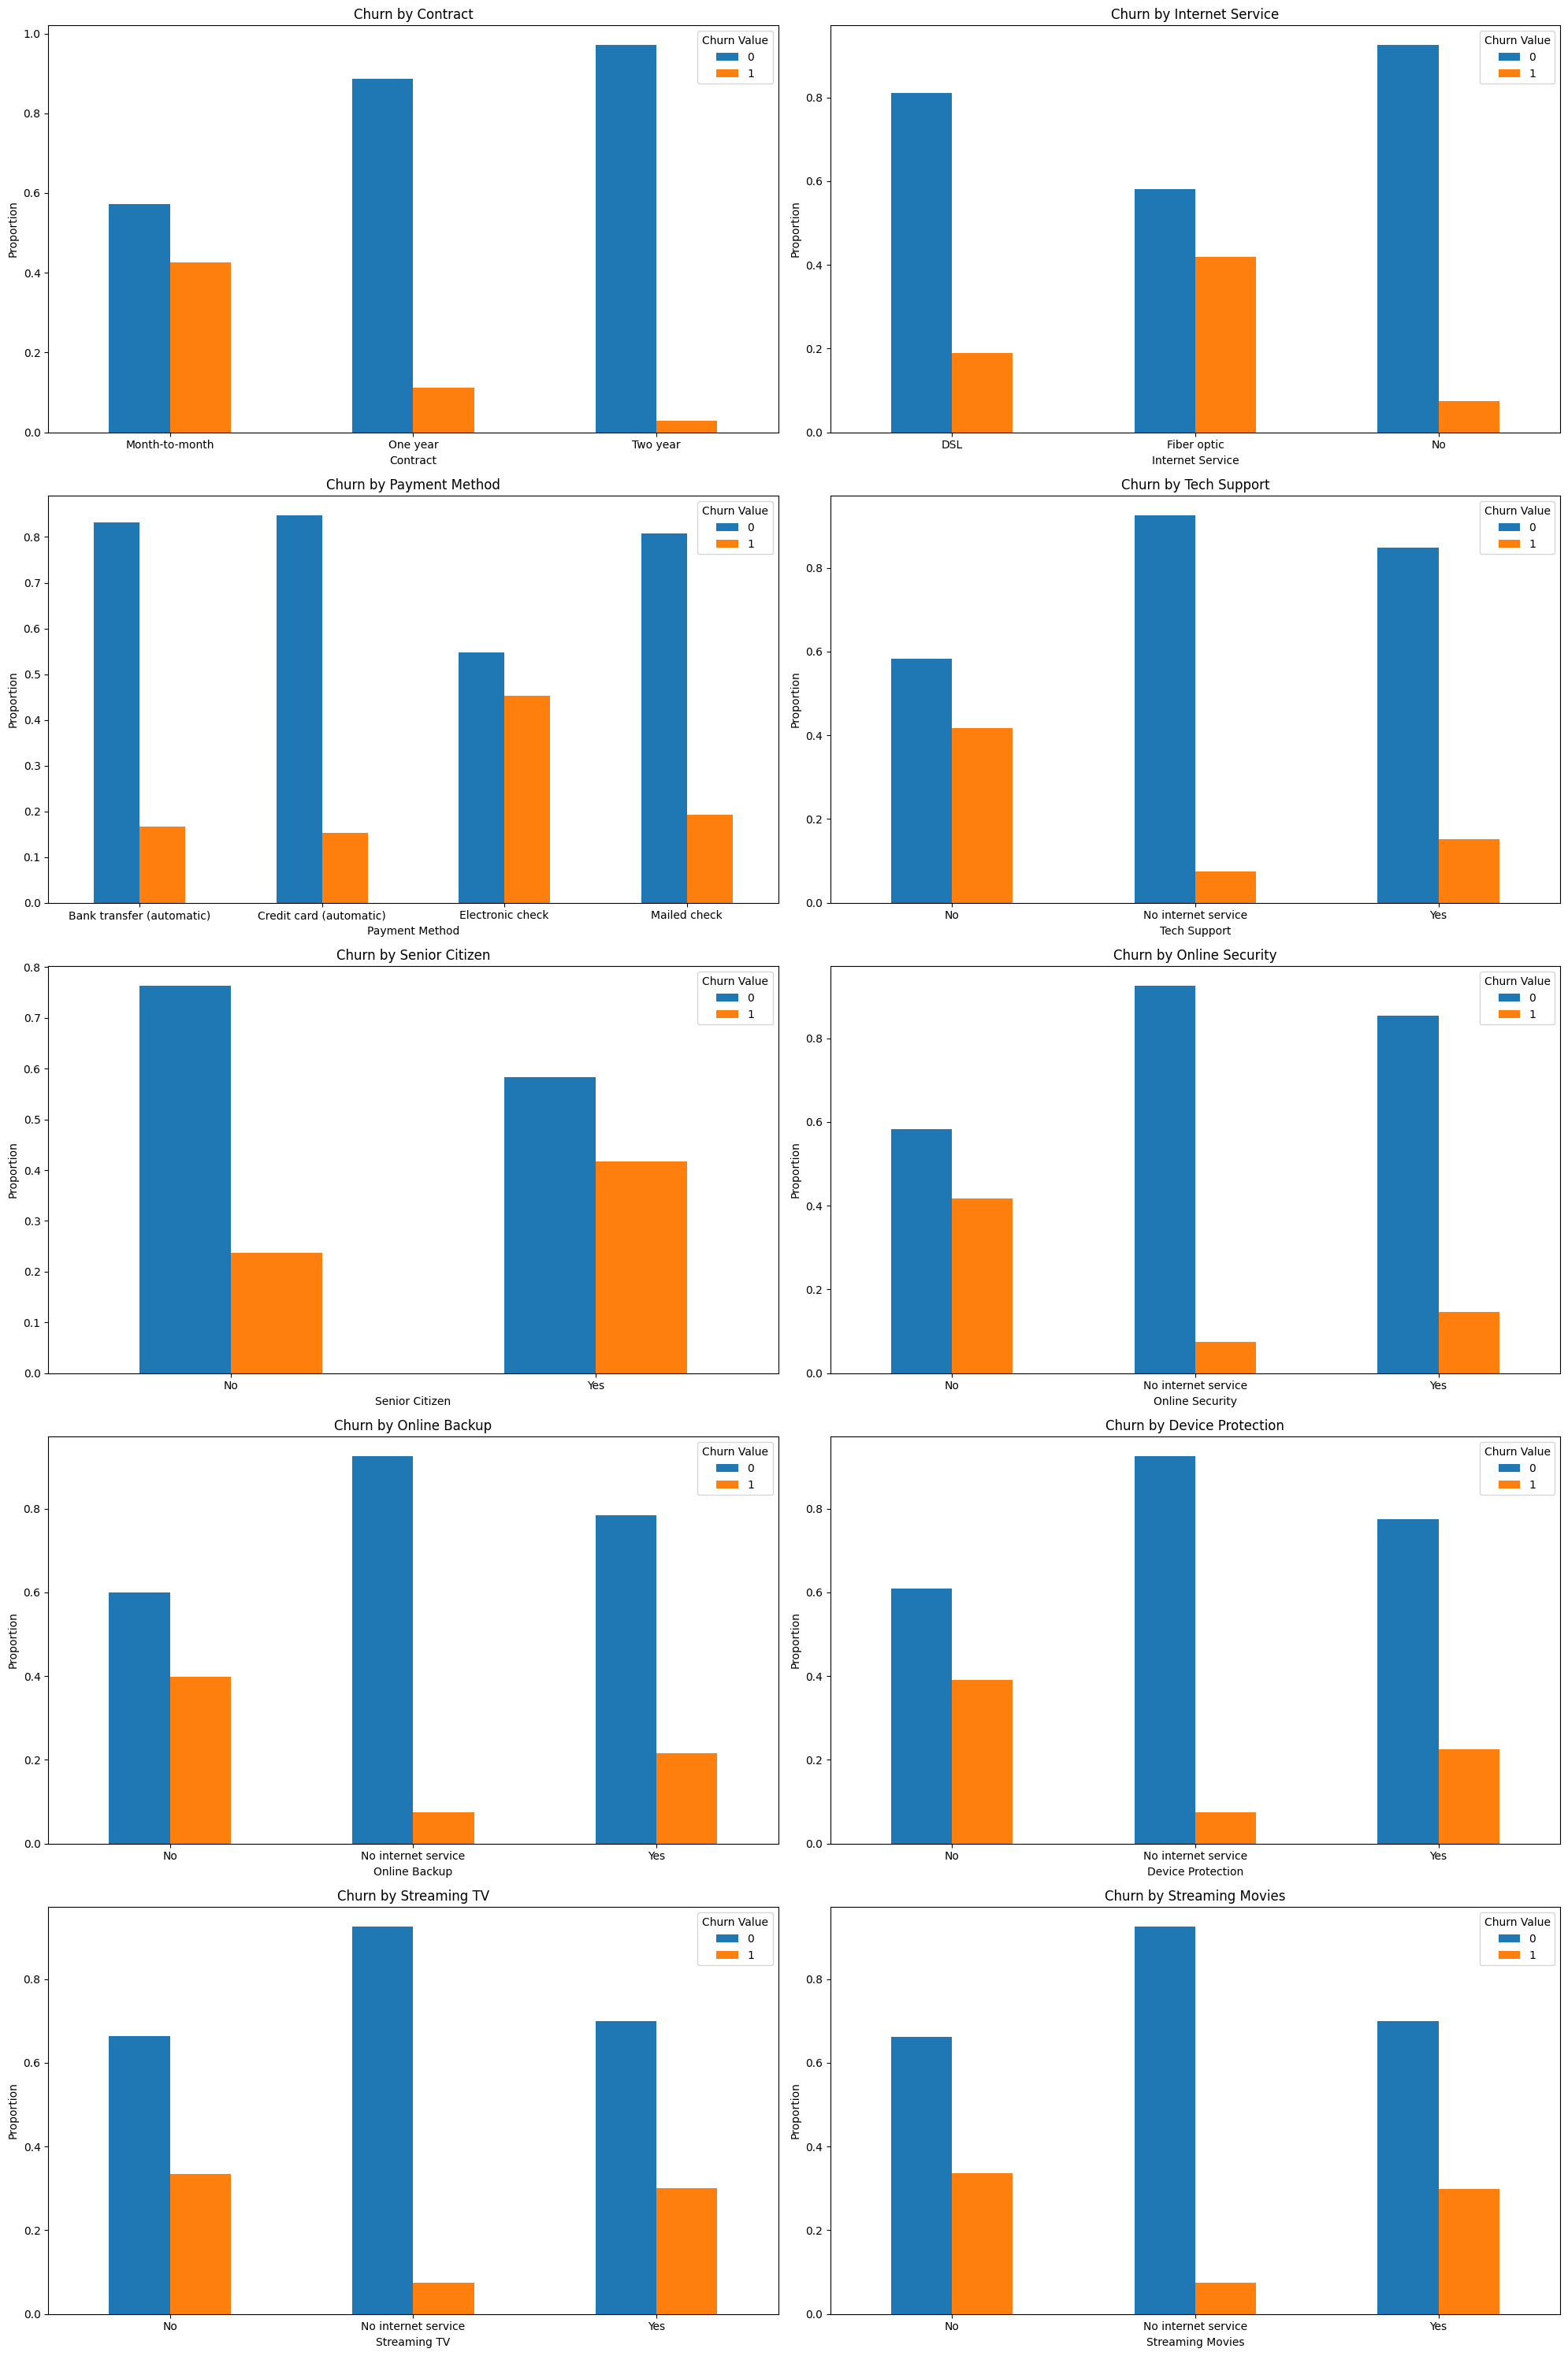

In [15]:
cat_cols = ['Contract', 'Internet Service', 'Payment Method', 'Tech Support', 'Senior Citizen','Online Security','Online Backup','Device Protection','Streaming TV','Streaming Movies']

fig, axes = plt.subplots(5, 2, figsize=(20, 30))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby(col)['Churn Value'].value_counts(normalize=True).unstack()
    ct.plot(kind='bar', ax=ax, title=f'Churn by {col}')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation = 360)
plt.tight_layout()
plt.show()

### Observation:
- **Contract type**: Month-to-month customers churn at `~41%`, the highest risk segment.
  One-year and two-year contract holders show much lower churn (~11% and ~3%).
  Contract type is expected to be a top feature.
- **Internet Service**: Fiber Optic customers churn at `~42%` versus ~19% for DSL users.
  Fiber customers likely pay premium prices and are more price-sensitive or seek
  better deals.
- **Payment Method**: Electronic check users churn at `~45%`, nearly 3x higher than
  customers on automatic payment methods (~15%). Manual payment may signal
  lower commitment or financial friction.
- Customers who have internet service but haven't subscribed to any add-on services are the most vulnerable segment

## 2. PreProcessing

In [16]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 non-n

### Drop Irrelevant Columns

In [18]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Score', 'CLTV'
]
df.drop(columns=drop_cols, inplace = True)
df.shape

(7032, 20)

### Encoding

In [19]:
binary_cat_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Paperless Billing', 'Phone Service']
for col in binary_cat_cols:
    df[col] = (df[col] == 'Yes').astype(int)
df['Gender'] = (df['Gender'] == 'Male').astype(int)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


In [20]:
df['Multiple Lines'] = df['Multiple Lines'].map({
    'No phone service': 0,
    'No': 1,
    'Yes': 2
})

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,1,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,1,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,2,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,2,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,2,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


In [21]:
addon_cols = ['Online Security', 'Online Backup', 'Device Protection',
              'Tech Support', 'Streaming TV', 'Streaming Movies']

addon_map = {
    'No internet service': 0,
    'No': 1,
    'Yes': 2
}
for col in addon_cols:
    df[col] = df[col].map(addon_map)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,1,DSL,2,2,1,1,1,1,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,1,Fiber optic,1,1,1,1,1,1,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,2,Fiber optic,1,1,2,1,2,2,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,2,Fiber optic,1,1,2,2,2,2,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,2,Fiber optic,1,2,2,1,2,2,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


In [22]:
df['AddOn Services'] = df[addon_cols].apply(
    lambda row: (row == 2).sum(), axis=1
)
df['AddOn Services'].value_counts().sort_index()

AddOn Services
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64

In [23]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,AddOn Services
0,1,0,0,0,2,1,1,DSL,2,2,1,1,1,1,Month-to-month,1,Mailed check,53.85,108.15,1,2
1,0,0,0,1,2,1,1,Fiber optic,1,1,1,1,1,1,Month-to-month,1,Electronic check,70.70,151.65,1,0
2,0,0,0,1,8,1,2,Fiber optic,1,1,2,1,2,2,Month-to-month,1,Electronic check,99.65,820.50,1,3
3,0,0,1,1,28,1,2,Fiber optic,1,1,2,2,2,2,Month-to-month,1,Electronic check,104.80,3046.05,1,4
4,1,0,0,1,49,1,2,Fiber optic,1,2,2,1,2,2,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1,4


In [24]:
multi_cat_cols = ['Internet Service', 'Contract', 'Payment Method']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False, dtype=int)
df.columns = df.columns.str.replace('_', ' ')
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Monthly Charges,Total Charges,Churn Value,AddOn Services,Internet Service DSL,Internet Service Fiber optic,Internet Service No,Contract Month-to-month,Contract One year,Contract Two year,Payment Method Bank transfer (automatic),Payment Method Credit card (automatic),Payment Method Electronic check,Payment Method Mailed check
0,1,0,0,0,2,1,1,2,2,1,1,1,1,1,53.85,108.15,1,2,1,0,0,1,0,0,0,0,0,1
1,0,0,0,1,2,1,1,1,1,1,1,1,1,1,70.70,151.65,1,0,0,1,0,1,0,0,0,0,1,0
2,0,0,0,1,8,1,2,1,1,2,1,2,2,1,99.65,820.50,1,3,0,1,0,1,0,0,0,0,1,0
3,0,0,1,1,28,1,2,1,1,2,2,2,2,1,104.80,3046.05,1,4,0,1,0,1,0,0,0,0,1,0
4,1,0,0,1,49,1,2,1,2,2,1,2,2,1,103.70,5036.30,1,4,0,1,0,1,0,0,1,0,0,0


In [25]:
df.shape

(7032, 28)

### Scaling

In [26]:
from sklearn.preprocessing import StandardScaler
scale_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

In [27]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Monthly Charges,Total Charges,Churn Value,AddOn Services,Internet Service DSL,Internet Service Fiber optic,Internet Service No,Contract Month-to-month,Contract One year,Contract Two year,Payment Method Bank transfer (automatic),Payment Method Credit card (automatic),Payment Method Electronic check,Payment Method Mailed check
0,1,0,0,0,-1.239504,1,1,2,2,1,1,1,1,1,-0.363923,-0.959649,1,2,1,0,0,1,0,0,0,0,0,1
1,0,0,0,1,-1.239504,1,1,1,1,1,1,1,1,1,0.196178,-0.940457,1,0,0,1,0,1,0,0,0,0,1,0
2,0,0,0,1,-0.995040,1,2,1,1,2,1,2,2,1,1.158489,-0.645369,1,3,0,1,0,1,0,0,0,0,1,0
3,0,0,1,1,-0.180161,1,2,1,1,2,2,2,2,1,1.329677,0.336516,1,4,0,1,0,1,0,0,0,0,1,0
4,1,0,0,1,0.675462,1,2,1,2,2,1,2,2,1,1.293113,1.214589,1,4,0,1,0,1,0,0,1,0,0,0


In [28]:
df.to_pickle('../data/processed/churn_processed.pkl')
print("Saved!")

Saved!


## 3. Model Training

### Split Input and Target Features

In [29]:
X = df.drop(columns=['Churn Value'])
Y = df['Churn Value']
X.shape, Y.shape

((7032, 27), (7032,))

### Train Test Split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# Step 1: split into temp train + test
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Step 2: split temp into train + validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp,
    test_size=0.25,
    random_state=42,
    stratify=Y_temp
)

# Check shapes and class balance
print(X_train.shape, X_val.shape, X_test.shape)
print(Y_train.mean().round(2), Y_val.mean().round(2), Y_test.mean().round(2))

(4218, 27) (1407, 27) (1407, 27)
0.27 0.27 0.27


In [32]:
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()
spw = neg / pos

print(f"Negatives: {neg}, Positives: {pos}")
print(f"scale_pos_weight: {spw:.2f}")

Negatives: 3097, Positives: 1121
scale_pos_weight: 2.76


#### `scale_pos_weight` makes XGBoost give more importance to the minority class by weighting its loss higher, so misclassifying churners has a larger impact during training. This is often simpler and more effective than using SMOTE for tree-based models

### Train XGBoost

In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds = 50,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42
)

In [34]:
xgb_model.fit(
    X_train, Y_train,
    eval_set=[(X_val, Y_val)],
    verbose = 50
)

print("\nTraining complete!")

[0]	validation_0-auc:0.82506
[50]	validation_0-auc:0.85381
[100]	validation_0-auc:0.85491
[128]	validation_0-auc:0.85479

Training complete!


In [35]:
print(xgb_model.best_iteration)
print(xgb_model.best_score)

78
0.8559864058269616


### Model Evaluation

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

In [37]:
Y_pred = xgb_model.predict(X_test)
Y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [38]:
print("ROC-AUC Score:", round(roc_auc_score(Y_test, Y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred, target_names=['No Churn', 'Churn']))

ROC-AUC Score: 0.8493

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1033
       Churn       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



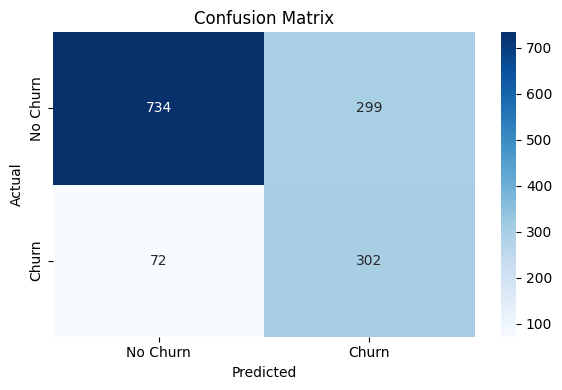

In [39]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

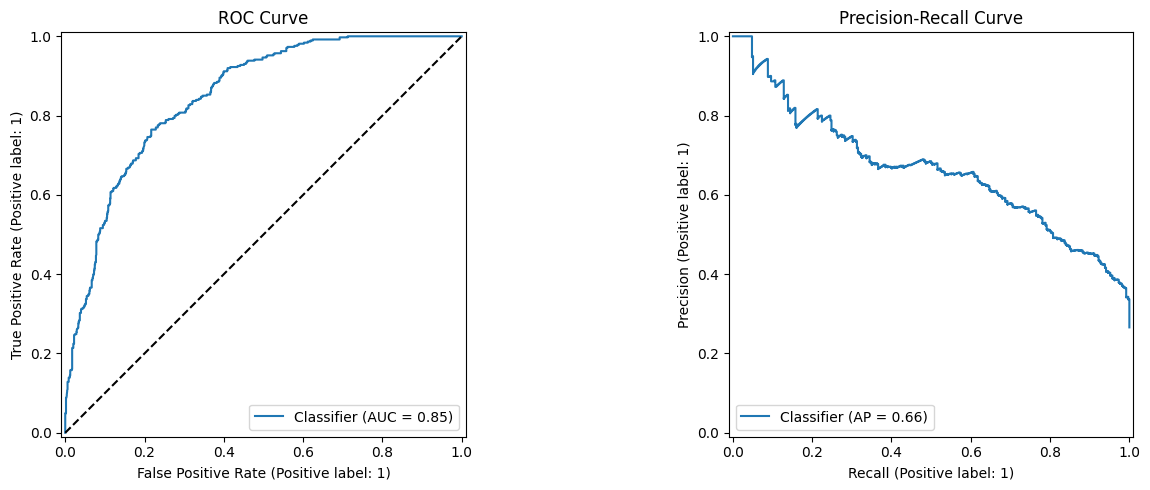

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(Y_test, Y_prob, ax=axes[0])
axes[0].set_title('ROC Curve')
axes[0].plot([0,1], [0,1], 'k--')

PrecisionRecallDisplay.from_predictions(Y_test, Y_prob, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [41]:
import joblib
joblib.dump(xgb_model, '../models/xgb_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Model and scaler saved!")

Model and scaler saved!


## 4. SHAP Explainability

In [42]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [43]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

SHAP values shape: (1407, 27)
X_test shape: (1407, 27)


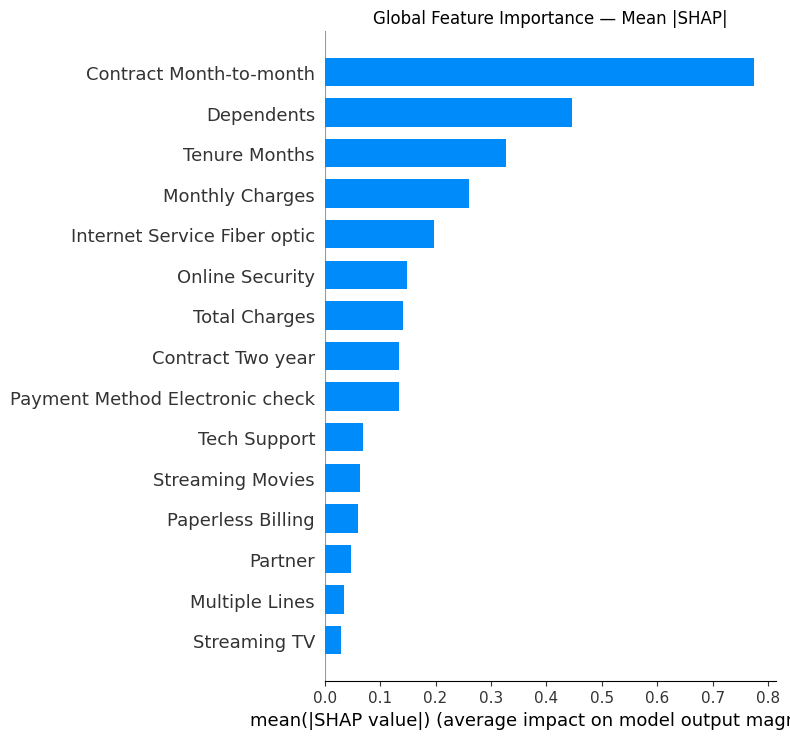

In [44]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Global Feature Importance — Mean |SHAP|")
plt.tight_layout()
plt.show()

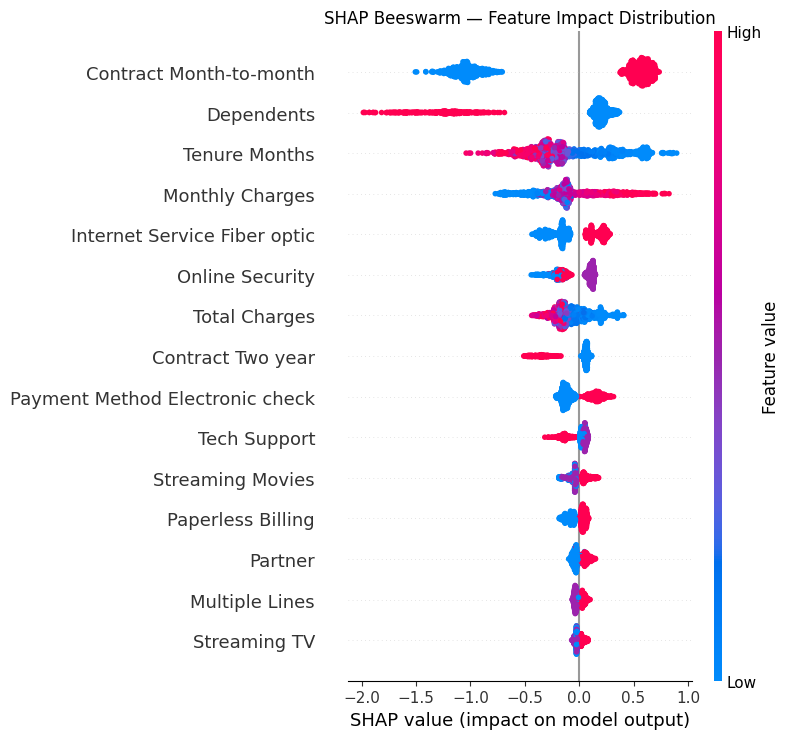

In [45]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Distribution")
plt.tight_layout()
plt.show()

### SHAP Analysis

**Contract Type is the Strongest Indicator of Customer Churn**

Customers who are on month-to-month plans are much more likely to leave the service. On the other hand, customers who choose longer commitments, especially two-year contracts, tend to stay with the company. This shows that encouraging long-term plans can significantly help in reducing customer churn.

**Customers with Dependents Are More Likely to Stay**

Customers who have dependents (such as family members relying on them) are much less likely to leave the service. This wasn’t very obvious during initial analysis, but the model shows it clearly — families tend to be more stable and loyal customers compared to individuals without dependents.


**Tenure and Monthly Charges Depend on the Situation**

The impact of how long a customer has stayed and how much they pay each month isn’t always straightforward. These factors don’t affect every customer in the same way. For example, a new customer paying a high price may be more likely to leave, while a long-term customer paying the same amount is more likely to stay. This shows that these factors need to be understood together rather than in isolation.


**Fiber Optic Customers Are More Likely to Leave**

Customers using fiber optic internet are more likely to stop using the service compared to others. Even though it is a premium offering, these customers tend to leave more often, possibly because of higher costs or better alternatives available in the market.


**Security and Support Services Help Retain Customers**

Customers who use services like online security and technical support are more likely to stay with the company. These services add real value and improve customer satisfaction. In contrast, entertainment options like streaming TV and movies do not have much impact on whether customers stay or leave. This suggests that practical, problem-solving services are far more effective at retaining customers than entertainment add-ons.


Customer index: 975
Actual label: 1
Predicted probability: 0.367


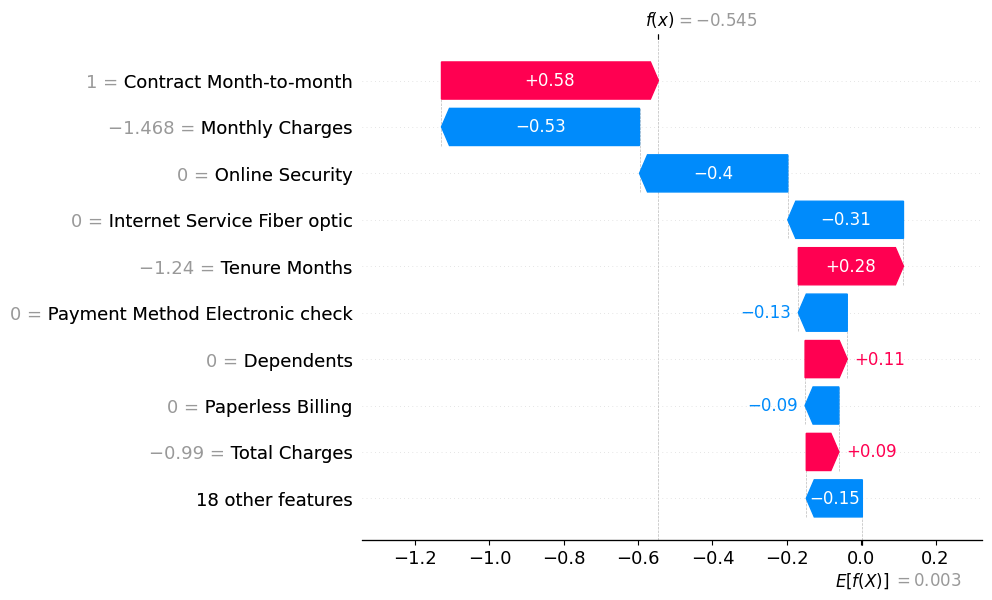

In [46]:
churner_idx = Y_test[Y_test == 1].index[0]
position = X_test.index.get_loc(churner_idx)

print(f"Customer index: {churner_idx}")
print(f"Actual label: {Y_test[churner_idx]}")
print(f"Predicted probability: {Y_prob[position]:.3f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test.iloc[position],
        feature_names=X_test.columns.tolist()
    )
)

In [47]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer saved!")

SHAP explainer saved!
